# AirShift — Feature Engineering

This notebook transforms the cleaned air quality data into meaningful features for the AirShift early-warning machine learning task.

The feature engineering process focuses on:

* Creating useful time-based features
* Capturing previous air quality conditions using lag features
* Measuring recent pollution patterns using rolling statistics
* Capturing changes and trends in air quality
* Preparing the data for defining future deterioration events

All features are created using information available at or before each observation to avoid future data leakage.


In [10]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/processed")

print("Processed data directory:")
print(DATA_DIR.resolve())

Processed data directory:
C:\Users\HP\Desktop\Projects\airshift\data\processed


In [3]:
cleaned_file = DATA_DIR / "airshift_cleaned.csv"

df = pd.read_csv(
    cleaned_file,
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)
print("\nFirst rows:")
df.head()

Dataset shape: (420768, 19)

First rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


## 1. Inspect Current Dataset

Before creating new features, we review the cleaned dataset to confirm its structure and the variables available for feature engineering.

This provides a baseline for deciding which temporal, historical, and trend-based features should be created.


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (420768, 19)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime']

Data types:
No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                     str
WSPM               float64
station                str
datetime    datetime64[us]
dtype: object


In [5]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


### Inspection Findings

The cleaned dataset contains 420,768 observations and 19 columns representing hourly air quality measurements from 12 monitoring stations.

The dataset includes pollutant, meteorological, temporal, station, and datetime variables. The data types and overall structure are appropriate for the feature engineering stage.

The dataset is ready for temporal ordering and the creation of new time-based and historical features.


## 2. Prepare Data for Feature Engineering

Before creating temporal features, the dataset is sorted by monitoring station and datetime.

This ensures that the observations are in the correct chronological order within each station. Proper ordering is essential for creating lag and rolling features based on previous observations.

All subsequent temporal features will be calculated separately within each monitoring station.


In [6]:
df = df.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

print("Data sorted by station and datetime.")

print("\nFirst rows after sorting:")
print(
    df[
        ["station", "datetime"]
    ].head()
)

Data sorted by station and datetime.

First rows after sorting:
        station            datetime
0  Aotizhongxin 2013-03-01 00:00:00
1  Aotizhongxin 2013-03-01 01:00:00
2  Aotizhongxin 2013-03-01 02:00:00
3  Aotizhongxin 2013-03-01 03:00:00
4  Aotizhongxin 2013-03-01 04:00:00


## 3. Time-Based Features

Air quality can vary depending on the time of day, day of the week, and season.

To capture these temporal patterns, new features are created from the existing `datetime` column. These features provide the model with additional information about when each observation occurred.

The time-based features include:

* `hour`: hour of the day.
* `day_of_week`: day of the week.
* `month`: month of the year.
* `is_weekend`: whether the observation occurred on a weekend.

These features are derived only from the observation timestamp and do not use any future information.


In [7]:
df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = df["datetime"].dt.dayofweek

df["month"] = df["datetime"].dt.month

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Time-based features created successfully.")

df[
    [
        "datetime",
        "hour",
        "day_of_week",
        "month",
        "is_weekend"
    ]
].head(10)

Time-based features created successfully.


,datetime,hour,day_of_week,month,is_weekend
0,2013-03-01 00:00:00,0,4,3,0
1,2013-03-01 01:00:00,1,4,3,0
2,2013-03-01 02:00:00,2,4,3,0
3,2013-03-01 03:00:00,3,4,3,0
4,2013-03-01 04:00:00,4,4,3,0
5,2013-03-01 05:00:00,5,4,3,0
6,2013-03-01 06:00:00,6,4,3,0
7,2013-03-01 07:00:00,7,4,3,0
8,2013-03-01 08:00:00,8,4,3,0
9,2013-03-01 09:00:00,9,4,3,0


### Time-Based Features Findings

The time-based features were created successfully from the `datetime` column.

The new features capture the hour of the day, day of the week, month, and whether an observation occurred on a weekend. These features provide the model with additional temporal context that may help capture recurring patterns in air quality.

All features are derived from the observation timestamp and do not use future information.


## 4. Lag Features

Air quality conditions are influenced by previous conditions, and changes in pollutant levels over time can provide important early warning signals.

Lag features capture the value of a variable from previous time points. For example, a one-hour lag of `PM2.5` represents the PM2.5 concentration measured one hour earlier.

For AirShift, lag features are created for the main pollutant variables using selected previous time intervals.

The lag intervals include:

* 1 hour
* 3 hours
* 6 hours

These features allow the model to compare the current air quality conditions with recent historical conditions while using only information available at or before the prediction time.


In [8]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

lag_hours = [1, 3, 6]

for column in pollutant_columns:
    for lag in lag_hours:
        df[f"{column}_lag_{lag}h"] = (
            df.groupby("station")[column]
              .shift(lag)
        )

print("Lag features created successfully.")

lag_columns = [
    column
    for column in df.columns
    if "_lag_" in column
]

print("\nLag features:")
print(lag_columns)

print("\nNumber of lag features:", len(lag_columns))

Lag features created successfully.

Lag features:
['PM2.5_lag_1h', 'PM2.5_lag_3h', 'PM2.5_lag_6h', 'PM10_lag_1h', 'PM10_lag_3h', 'PM10_lag_6h', 'SO2_lag_1h', 'SO2_lag_3h', 'SO2_lag_6h', 'NO2_lag_1h', 'NO2_lag_3h', 'NO2_lag_6h', 'CO_lag_1h', 'CO_lag_3h', 'CO_lag_6h', 'O3_lag_1h', 'O3_lag_3h', 'O3_lag_6h']

Number of lag features: 18


### Validate Lag Features

After creating the lag features, their values are inspected to verify that they correctly represent previous observations within each monitoring station.

The first observations of each station are expected to contain missing values because previous measurements are not available for those timestamps.

This validation ensures that lag features are calculated in chronological order and do not use information from other stations or future observations.


In [9]:
df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_lag_1h",
        "PM2.5_lag_3h",
        "PM2.5_lag_6h"
    ]
].head(10)

,station,datetime,PM2.5,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,4.0,NaN,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,8.0,NaN,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,7.0,4.0,NaN
4,Aotizhongxin,2013-03-01 04:00:00,3.0,6.0,8.0,NaN
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0,7.0,NaN
6,Aotizhongxin,2013-03-01 06:00:00,3.0,5.0,6.0,4.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0,3.0,8.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,3.0,5.0,7.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,3.0,3.0,6.0


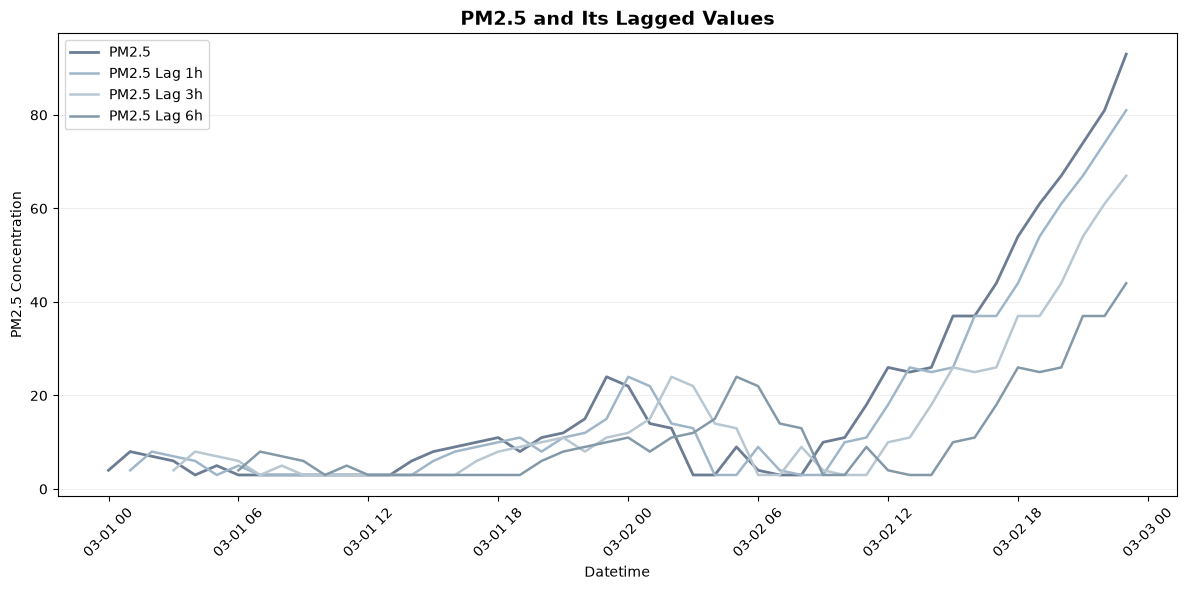

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\feature_engineering\figure_04_pm25_and_lagged_values.png


In [12]:
# Create the Feature Engineering figures directory
FIGURES_DIR = Path("../reports/figures/feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Select one station and a short time period for visualization
plot_data = df[
    df["station"] == "Aotizhongxin"
].iloc[:48].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5"],
    label="PM2.5",
    color="#6B7C93",
    linewidth=2
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_1h"],
    label="PM2.5 Lag 1h",
    color="#9FB6C9",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_3h"],
    label="PM2.5 Lag 3h",
    color="#B8C7D1",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_6h"],
    label="PM2.5 Lag 6h",
    color="#8499A8",
    linewidth=1.8
)

plt.title(
    "PM2.5 and Its Lagged Values",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Datetime")
plt.ylabel("PM2.5 Concentration")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=45)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_04_pm25_and_lagged_values.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())